In [1]:
dvc = 'cpu'
from dolfinx import fem, mesh as msh
from dolfinx.io import XDMFFile
from mpi4py import MPI
from FEniCSx_solver import plot_fn
import torch
import ufl
import numpy as np
from FEniCSx_solver import interpolate_expr, SUPG_grad_adjoint_method_solver
from FEniCSx_PyTorch_interface import fem_solver


G = torch.load(f='data/revised_set/input_values/raw/G_0.pt', weights_only=False).to(device=dvc)

with XDMFFile(MPI.COMM_WORLD, f"data/revised_set/mesh_files/mesh_{0}.xdmf", "r") as xdmf:
    mesh = xdmf.read_mesh(name="mesh")
Wh = fem.functionspace(mesh=mesh, element=('CG', 1))
Whd = fem.functionspace(mesh=mesh, element=('DG', 0))
ufun = fem.Function(Wh)
ufun_d = fem.Function(Whd)
u = ufl.TrialFunction(Wh)
v = ufl.TestFunction(Wh)

mesh.topology.create_connectivity(1, 2)
boundary_facets = msh.exterior_facet_indices(mesh.topology)
boundary_dofs = fem.locate_dofs_topological(Wh, 1, boundary_facets)

x = ufl.SpatialCoordinate(mesh)
b = ufl.as_vector((fem.Constant(mesh, np.cos(-np.pi/3.0)), fem.Constant(mesh, np.sin(-np.pi/3.0))))
f = fem.Constant(mesh, 0.0)
eps = fem.Constant(mesh, 1e-8)

u = ufl.TrialFunction(Wh)
v = ufl.TestFunction(Wh)


expr = ufl.conditional(
    ufl.ge(x[1], 0.7 + ufl.sin(-ufl.pi/3)/ufl.cos(-ufl.pi/3)*x[0]),
    1,
    0
) * ufl.conditional(
    ufl.Or(ufl.eq(x[1], 0), ufl.eq(x[0],1)),
    0,
    1
)
uD = interpolate_expr(expr=expr, Wh=Wh)
bcs = [fem.dirichletbc(uD, boundary_dofs)]
pde_data = mesh,Wh,ufun,eps,b,None,f,None,bcs

u_target = fem.Function(Wh)
u_target.x.array[:] = torch.clone(G.u_bjk).cpu().detach().numpy()
loss_form = (ufun-u_target)**2 * ufl.dx
fs = fem_solver(SUPG_grad_adjoint_method_solver(pde_data=pde_data, loss_form=loss_form))




# Models and training

In [2]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from IPython.display import clear_output
import numpy as np
import matplotlib.pyplot as plt

dvc = 'cpu'
G = torch.load(f='data/revised_set/input_values/raw/G_0.pt', weights_only=False).to(device=dvc)
idofs = torch.clone(G.interior_dofs)


X = torch.clone(G.midpoints[:,0]).cpu().detach().numpy().flatten()
Y = torch.clone(G.midpoints[:,1]).cpu().detach().numpy().flatten()

Z0 = torch.clone(G.y_optimized_z).cpu().detach().numpy().flatten()
Z1 = torch.clone(G.y_optimized_z).cpu().detach().numpy().flatten()
Z2 = torch.clone(G.y_optimized_z).cpu().detach().numpy().flatten()
Zsp = torch.clone(G.y_optimized_z).cpu().detach().numpy().flatten()

z0 = torch.clone(G.y_optimized_z)
z1 = torch.clone(G.y_optimized_z)
z2 = torch.clone(G.y_optimized_z)
zsp = torch.clone(G.y_optimized_z)

curr_loss0 = 1e-2
curr_loss1 = 1e-2
curr_loss2 = 1e-2
curr_losssp = 1e-2

target = torch.clone(G.y_optimized_z)


class NN(torch.nn.Module):
    def __init__(self, n:int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(n, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 64),
            nn.Sigmoid(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 64),
            nn.Sigmoid(),
            nn.Linear(64, 256),
            nn.ReLU(),
        ).to(device=dvc)
        self.mlp_main = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        ).to(device=dvc)
        self.mlp_aux = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        ).to(device=dvc)
    def forward(self, data) -> torch.Tensor:
        z1 = self.mlp(data)
        z_main = self.mlp_main(z1)
        z_aux = self.mlp_aux(z1)
        return z_main, z_aux
    
model0 = NN(9)
model1 = NN(11)
model2 = NN(4)
modelsp = NN(2)



huber = torch.nn.HuberLoss(reduction='sum')
l2 = torch.nn.MSELoss(reduction='sum')
def loss_fn(pred, target):
    return 0.7*huber(pred[0], target) + 0.3*l2(pred[1], target)

dataset = TensorDataset(G.x0[idofs], G.x1[idofs], G.x2[idofs], G.midpoints[idofs], target[idofs])
batch_size = 1024
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,   # important for SGD
    drop_last=False  # optional
)

optimizer0 = torch.optim.Adam(model0.parameters(), lr=1e-3, weight_decay=1e-5)
optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-5)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-5)
optimizersp = torch.optim.Adam(modelsp.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler0 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer=optimizer0, T_0=50, T_mult=2)
scheduler1 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer=optimizer1, T_0=50, T_mult=2)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer=optimizer2, T_0=50, T_mult=2)
schedulersp = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer=optimizersp, T_0=50, T_mult=2)

scheduler_r0 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer0, factor=0.1, patience=50)
scheduler_r1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer1, factor=0.1, patience=50)
scheduler_r2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer2, factor=0.1, patience=50)
scheduler_rsp = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizersp, factor=0.1, patience=50)

losses0 = []
losses1 = []
losses2 = []
lossessp = []

losses_act0 = []
losses_act1 = []
losses_act2 = []
losses_actsp = []


In [3]:
checkpoint0 = torch.load("data/models/revised0.pth", map_location=dvc)
model0.load_state_dict(checkpoint0["model_state"])
optimizer0.load_state_dict(checkpoint0["optimizer_state"])
curr_loss0 = checkpoint0.get("loss")

checkpoint1 = torch.load("data/models/revised1.pth", map_location="cpu")
model1.load_state_dict(checkpoint1["model_state"])
optimizer1.load_state_dict(checkpoint1["optimizer_state"])
curr_loss1 = checkpoint1.get("loss")


checkpoint2 = torch.load("data/models/revised2.pth", map_location="cpu")
model2.load_state_dict(checkpoint2["model_state"])
optimizer2.load_state_dict(checkpoint2["optimizer_state"])
curr_loss2 = checkpoint2.get("loss")


checkpointsp = torch.load("data/models/revisedsp.pth", map_location="cpu")
modelsp.load_state_dict(checkpointsp["model_state"])
optimizersp.load_state_dict(checkpointsp["optimizer_state"])
curr_losssp = checkpointsp.get("loss")


lossarr0 = np.load('data/loss_arrays/sup_loss_x0.npy')
lossarr1 = np.load('data/loss_arrays/sup_loss_x1.npy')
lossarr2 = np.load('data/loss_arrays/sup_loss_x2.npy')
lossarrsp = np.load('data/loss_arrays/sup_loss_xsp.npy')

act_lossarr0 = np.load('data/loss_arrays/act_sup_loss_x0.npy')
act_lossarr1 = np.load('data/loss_arrays/act_sup_loss_x1.npy')
act_lossarr2 = np.load('data/loss_arrays/act_sup_loss_x2.npy')
act_lossarrsp = np.load('data/loss_arrays/act_sup_loss_xsp.npy')



z0 = torch.clone(G.y_optimized_z)
z1 = torch.clone(G.y_optimized_z)
z2 = torch.clone(G.y_optimized_z)
zsp = torch.clone(G.y_optimized_z)


z0[idofs] = model0(G.x0)[0][idofs]
z1[idofs] = model1(G.x1)[0][idofs]
z2[idofs] = model2(G.x2)[0][idofs]
zsp[idofs] = modelsp(G.midpoints)[0][idofs]


act_loss0 = fs(z0)
act_loss1 = fs(z1)
act_loss2 = fs(z2)
act_losssp = fs(zsp)

print(act_loss0, act_loss1, act_loss2, act_losssp)

tensor(9.6433e-06, grad_fn=<FEniCSx_PyTorch_interfaceBackward>) tensor(4.4894e-05, grad_fn=<FEniCSx_PyTorch_interfaceBackward>) tensor(0.0022, grad_fn=<FEniCSx_PyTorch_interfaceBackward>) tensor(2.2229e-06, grad_fn=<FEniCSx_PyTorch_interfaceBackward>)


In [4]:
from FEniCSx_solver import plot_fn
fs.fs.set_weights(torch.clone(z0).detach().cpu().detach().numpy().flatten())
plot_fn(fs.fs.uh)

Widget(value='<iframe src="http://localhost:63070/index.html?ui=P_0x344991fd0_0&reconnect=auto" class="pyvista…

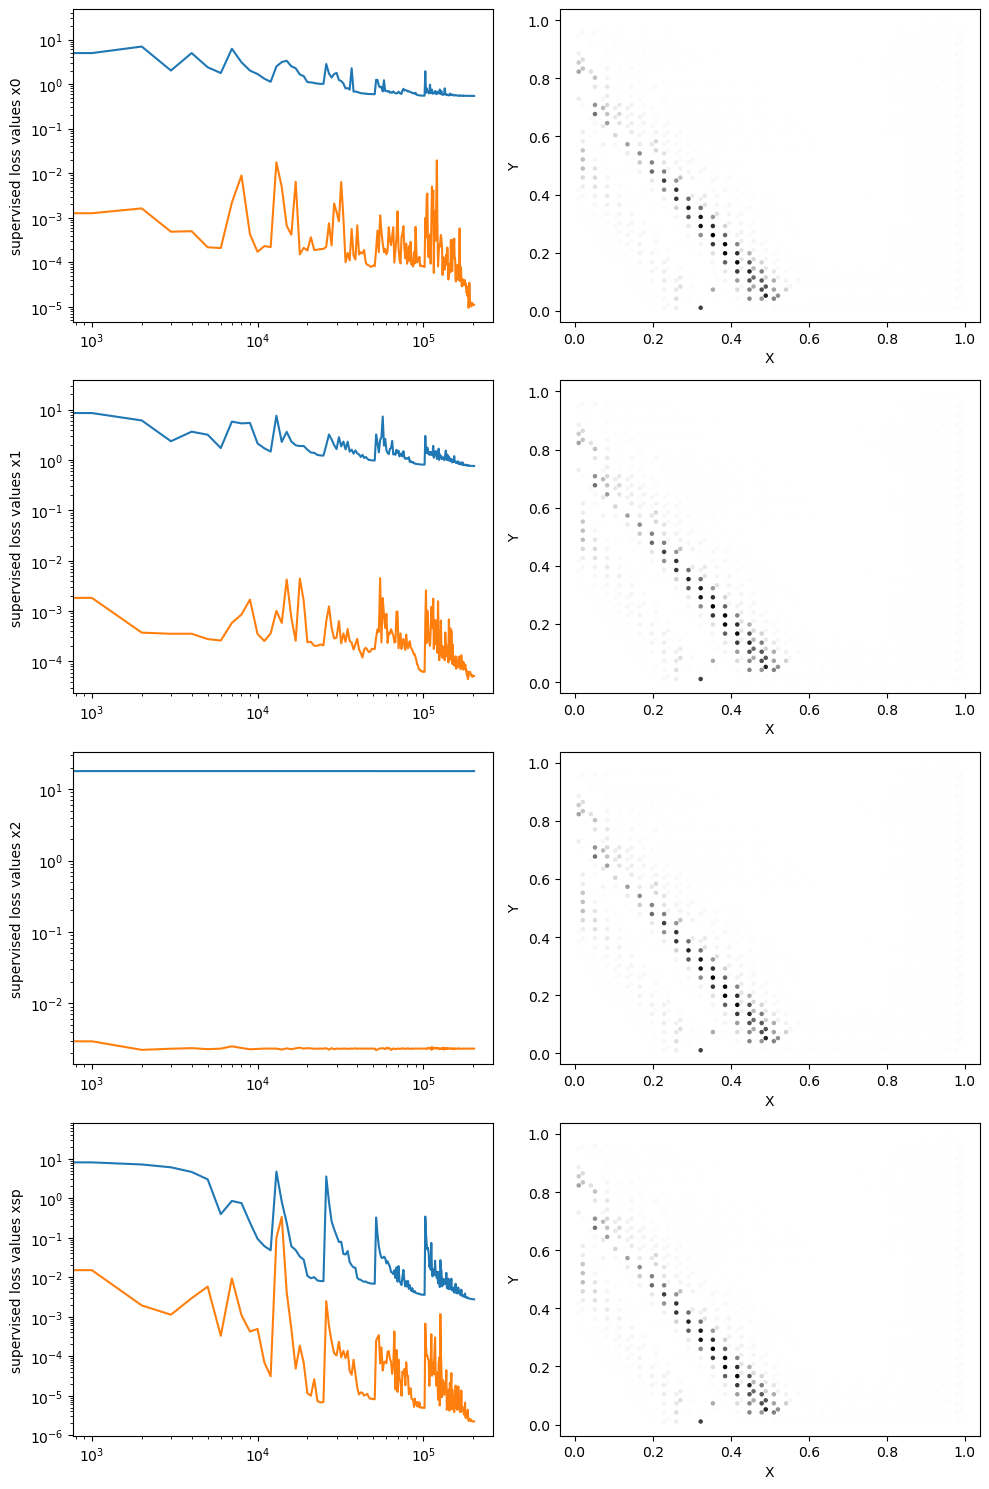

In [6]:
import numpy as np
import matplotlib.pyplot as plt
lossarr0 = np.load('data/loss_arrays/sup_loss_x0.npy')
lossarr1 = np.load('data/loss_arrays/sup_loss_x1.npy')
lossarr2 = np.load('data/loss_arrays/sup_loss_x2.npy')
lossarrsp = np.load('data/loss_arrays/sup_loss_xsp.npy')

act_lossarr0 = np.load('data/loss_arrays/act_sup_loss_x0.npy')
act_lossarr1 = np.load('data/loss_arrays/act_sup_loss_x1.npy')
act_lossarr2 = np.load('data/loss_arrays/act_sup_loss_x2.npy')
act_lossarrsp = np.load('data/loss_arrays/act_sup_loss_xsp.npy')


X = torch.clone(G.midpoints[:,0]).cpu().detach().numpy().flatten()
Y = torch.clone(G.midpoints[:,1]).cpu().detach().numpy().flatten()

Z0 = torch.clone(G.y_optimized_z).cpu().detach().numpy().flatten()
Z1 = torch.clone(G.y_optimized_z).cpu().detach().numpy().flatten()
Z2 = torch.clone(G.y_optimized_z).cpu().detach().numpy().flatten()
Zsp = torch.clone(G.y_optimized_z).cpu().detach().numpy().flatten()

x_vals = 1000*np.arange(len(lossarr0))
fig, axes = plt.subplots(4, 2, figsize=(10, 15))

ax11, ax12, ax21, ax22, ax31, ax32, ax41, ax42 = axes.flatten()

ax11.plot(x_vals, lossarr0,  label='supervised_loss x0')
ax11.plot(x_vals, act_lossarr0,  label='supervised_loss x0')
ax11.set_ylabel('supervised loss values x0')

ax11.set_yscale('log')
ax11.set_xscale('log')
ax11.tick_params(axis='y')

ax21.plot(x_vals, lossarr1,  label='supervised_loss x1')
ax21.plot(x_vals, act_lossarr1,  label='supervised_loss x1')
ax21.set_ylabel('supervised loss values x1')

ax21.set_yscale('log')
ax21.set_xscale('log')
ax21.tick_params(axis='y')


ax31.plot(x_vals, lossarr2,  label='supervised_loss x2')
ax31.plot(x_vals, act_lossarr2,  label='supervised_loss x2')
ax31.set_ylabel('supervised loss values x2')

ax31.set_yscale('log')
ax31.set_xscale('log')
ax31.tick_params(axis='y')


ax41.plot(x_vals, lossarrsp,  label='supervised_loss sp')
ax41.plot(x_vals, act_lossarrsp,  label='supervised_loss sp')
ax41.set_ylabel('supervised loss values xsp')

ax41.set_yscale('log')
ax41.set_xscale('log')
ax41.tick_params(axis='y')
ax12.scatter(X, Y, s=5, c=Z0, cmap='Greys')
ax12.set_xlabel('X')
ax12.set_ylabel('Y')

ax22.scatter(X, Y, s=5, c=Z1, cmap='Greys')
ax22.set_xlabel('X')
ax22.set_ylabel('Y')

ax32.scatter(X, Y, s=5, c=Z2, cmap='Greys')
ax32.set_xlabel('X')
ax32.set_ylabel('Y')

ax42.scatter(X, Y, s=5, c=Zsp, cmap='Greys')
ax42.set_xlabel('X')
ax42.set_ylabel('Y')


plt.tight_layout()
plt.show()

In [ ]:
'''
step = 1000
for i in range(1000000):
    for x0, x1, x2, xsp, yb in loader:
        pred0 = model0(x0)
        pred1 = model1(x1)
        pred2 = model2(x2)
        predsp = modelsp(xsp)
        
        loss0 = loss_fn(pred0, yb)
        loss1 = loss_fn(pred1, yb)
        loss2 = loss_fn(pred2, yb)
        losssp = loss_fn(predsp, yb)

        loss0.backward()
        loss1.backward()
        loss2.backward()
        losssp.backward()
        torch.nn.utils.clip_grad_norm_(
            model0.parameters(),
            max_norm=1.0
        )
        torch.nn.utils.clip_grad_norm_(
            model1.parameters(),
            max_norm=1.0
        )
        torch.nn.utils.clip_grad_norm_(
            model2.parameters(),
            max_norm=1.0
        )
        torch.nn.utils.clip_grad_norm_(
            modelsp.parameters(),
            max_norm=1.0
        )
        
        optimizer0.step()
        optimizer1.step()
        optimizer2.step()
        optimizersp.step()

        optimizer0.zero_grad()
        optimizer1.zero_grad()
        optimizer2.zero_grad()
        optimizersp.zero_grad()

        scheduler0.step()
        scheduler1.step()
        scheduler2.step()
        schedulersp.step()
        
        scheduler_r0.step(loss0)
        scheduler_r1.step(loss1)
        scheduler_r2.step(loss2)
        scheduler_rsp.step(losssp)

    if i%step == 0:
        Z0[idofs] = torch.clone(model0(G.x0)[0]).cpu().detach().numpy().flatten()[idofs]
        Z1[idofs] = torch.clone(model1(G.x1)[0]).cpu().detach().numpy().flatten()[idofs]
        Z2[idofs] = torch.clone(model2(G.x2)[0]).cpu().detach().numpy().flatten()[idofs]
        Zsp[idofs] = torch.clone(modelsp(G.midpoints)[0]).cpu().detach().numpy().flatten()[idofs]
        z0[idofs] = model0(G.x0)[0][idofs]
        z1[idofs] = model1(G.x1)[0][idofs]
        z2[idofs] = model2(G.x2)[0][idofs]
        zsp[idofs] = modelsp(G.midpoints)[0][idofs]

        clear_output()
        losses0.append(loss_fn(model0(G.x0[idofs]), target[idofs]).item())
        losses1.append(loss_fn(model1(G.x1[idofs]), target[idofs]).item())
        losses2.append(loss_fn(model2(G.x2[idofs]), target[idofs]).item())
        lossessp.append(loss_fn(modelsp(G.midpoints[idofs]), target[idofs]).item())

        act_loss0 = fs(z0)
        act_loss1 = fs(z1)
        act_loss2 = fs(z2)
        act_losssp = fs(zsp)

        losses_act0.append(act_loss0.item())
        losses_act1.append(act_loss1.item())
        losses_act2.append(act_loss2.item())
        losses_actsp.append(act_losssp.item())

        if curr_loss0 > act_loss0:    
            print(f"iteration {i}: new loss0: {act_loss0}")
            curr_loss0 = act_loss0
            torch.save({'model_state': model0.state_dict(), 'optimizer_state': optimizer0.state_dict(), 'loss': act_loss0}, "data/models/revised0.pth")
        if curr_loss1 > act_loss1:    
            print(f"iteration {i}: new loss1: {act_loss1}")
            curr_loss1 = act_loss1
            torch.save({'model_state': model1.state_dict(), 'optimizer_state': optimizer1.state_dict(), 'loss': act_loss1}, "data/models/revised1.pth")
        if curr_loss2 > act_loss2:    
            print(f"iteration {i}: new loss2: {act_loss2}")
            curr_loss2 = act_loss2
            torch.save({'model_state': model2.state_dict(), 'optimizer_state': optimizer2.state_dict(), 'loss': act_loss2}, "data/models/revised2.pth")
        if curr_losssp > act_losssp:    
            print(f"iteration {i}: new losssp: {act_losssp}")
            curr_losssp = act_losssp
            torch.save({'model_state': modelsp.state_dict(), 'optimizer_state': optimizersp.state_dict(), 'loss': act_losssp}, "data/models/revisedsp.pth")

        print(f"epoch: {i}, supervised_loss 0: {loss0.item():3e}, supervised_loss 2: {loss1.item():3e}, supervised_loss 2: {loss2.item():3e}, supervised_loss sp: {losssp.item():3e}")
        lossarr0 = np.array(losses0)
        lossarr1 = np.array(losses1)
        lossarr2 = np.array(losses2)
        lossarrsp = np.array(lossessp)

        act_lossarr0 = np.array(losses_act0)
        act_lossarr1 = np.array(losses_act1)
        act_lossarr2 = np.array(losses_act2)
        act_lossarrsp = np.array(losses_actsp)

        x_vals = step*np.arange(len(lossarr0))
        fig, axes = plt.subplots(4, 2, figsize=(10, 15))

        ax11, ax12, ax21, ax22, ax31, ax32, ax41, ax42 = axes.flatten()

        ax11.plot(x_vals, lossarr0,  label='supervised_loss x0')
        ax11.plot(x_vals, act_lossarr0,  label='supervised_loss x0')
        ax11.set_ylabel('supervised loss values x0')

        ax11.set_yscale('log')
        ax11.tick_params(axis='y')

        ax21.plot(x_vals, lossarr1,  label='supervised_loss x1')
        ax21.plot(x_vals, act_lossarr1,  label='supervised_loss x1')
        ax21.set_ylabel('supervised loss values x1')

        ax21.set_yscale('log')
        ax21.tick_params(axis='y')

       
        ax31.plot(x_vals, lossarr2,  label='supervised_loss x2')
        ax31.plot(x_vals, act_lossarr2,  label='supervised_loss x2')
        ax31.set_ylabel('supervised loss values x2')

        ax31.set_yscale('log')
        ax31.tick_params(axis='y')

       
        ax41.plot(x_vals, lossarrsp,  label='supervised_loss sp')
        ax41.plot(x_vals, act_lossarrsp,  label='supervised_loss sp')
        ax41.set_ylabel('supervised loss values xsp')

        ax41.set_yscale('log')
        ax41.tick_params(axis='y')
        ax12.scatter(X, Y, s=5, c=Z0, cmap='Greys')
        ax12.set_xlabel('X')
        ax12.set_ylabel('Y')

        ax22.scatter(X, Y, s=5, c=Z1, cmap='Greys')
        ax22.set_xlabel('X')
        ax22.set_ylabel('Y')

        ax32.scatter(X, Y, s=5, c=Z2, cmap='Greys')
        ax32.set_xlabel('X')
        ax32.set_ylabel('Y')

        ax42.scatter(X, Y, s=5, c=Zsp, cmap='Greys')
        ax42.set_xlabel('X')
        ax42.set_ylabel('Y')

        np.save('data/loss_arrays/sup_loss_x0.npy', lossarr0)
        np.save('data/loss_arrays/sup_loss_x1.npy', lossarr1)
        np.save('data/loss_arrays/sup_loss_x2.npy', lossarr2)
        np.save('data/loss_arrays/sup_loss_xsp.npy', lossarrsp)



        np.save('data/loss_arrays/act_sup_loss_x0.npy', act_lossarr0)
        np.save('data/loss_arrays/act_sup_loss_x1.npy', act_lossarr1)
        np.save('data/loss_arrays/act_sup_loss_x2.npy', act_lossarr2)
        np.save('data/loss_arrays/act_sup_loss_xsp.npy', act_lossarrsp)


        plt.tight_layout()
        plt.show()
'''